\*Doble click para ver comandos de LaTex*
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\had}[1]{  \frac{\ket{0}#1\ket{1}}{\sqrt{2}} } $

*Asegurate de tener instalado estas dependencias en tu noteboook*

In [1]:
%%capture
# -------------------------------------------------------------
# Instalamos dependencias y paquetes
# -------------------------------------------------------------

!pip install qiskit                         #Qiskit
!pip install qiskit-aer                     #simulador cuántico local
!pip install pylatexenc                     #renderiza latex dentro de gráficos
#!pip install qiskit-ibm-runtime            #Solo para ejecutar en hardware real

# Si tienes problemas para ejecutar luego de haber instalado, restaura la sesión: Runtime > Restart session

## Ejercicio 2.32 - Wong

Pruebe que $HXH=Z$ mostrando que $HXH\ket{0}$ y $Z\ket{0}$ resultan en el mismo estado y $HXH\ket{1}$ y $Z\ket{1}$ también.

**Sol.**
\begin{align*}
HXH\ket{0} &= HX\left(\had{+}\right) = \frac{1}{\sqrt{2}}H\left(X\ket{0}+X\ket{1}\right)\\
          &= \frac{1}{\sqrt{2}}H\left(\ket{1}+\ket{0}\right)
          = \frac{1}{\sqrt{2}}\left(H\ket{1}+H\ket{0}\right)\\
          &=\frac{1}{\sqrt{2}}\left(\had{-}+\had{+}\right)
          =\frac{1}{\sqrt{2}}\left(\frac{2}{\sqrt{2}}\ket{0}\right)\\
          &=\ket{0}\\
          &=Z\ket{0}
\end{align*}

\begin{align*}
HXH\ket{1} &= HX\left(\had{-}\right) = \frac{1}{\sqrt{2}}H\left(X\ket{0}-X\ket{1}\right)\\
          &= \frac{1}{\sqrt{2}}H\left(\ket{1}-\ket{0}\right)
          = \frac{1}{\sqrt{2}}\left(H\ket{1}-H\ket{0}\right)\\
          &=\frac{1}{\sqrt{2}}\left(\had{-}-\had{+}\right)
          =\frac{1}{\sqrt{2}}\left(-\frac{2}{\sqrt{2}}\ket{1}\right)\\
          &=-\ket{1}\\
          &=Z\ket{1}
\end{align*}

<br/>

Por tanto podemos decir que $HXH=Z$

## 3. Verificación con Qiskit


In [2]:
# -------------------------------------------------------------
# Ejercicio: 2.32 Wong
# -------------------------------------------------------------

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

#Creamos un circuito con un solo qubit
qc = QuantumCircuit(1)

#Añadimos una compuerta H, X, H
qc.h(0)
qc.x(0)
qc.h(0)

#Evaluamos el estado del qubit
state0 = Statevector.from_instruction(qc)

#Visualizamos el estado
print('Estado del qubit despues de aplicar HXH: ', state0.data)


Estado del qubit despues de aplicar HXH:  [1.+0.j 0.+0.j]


Note que el resultado `[1.+0.j 0.+0.j]` es igual a $Z\ket{0}=\vzero$. Ahora veamos el caso para $HXH\ket{1}$

In [3]:
# -------------------------------------------------------------
# Ejercicio: 2.32 Wong
# -------------------------------------------------------------

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

#Creamos un circuito con un solo qubit
qc = QuantumCircuit(1)

#Inicializamos el estado del qubit a |->
alpha = 0
beta = 1
qc.initialize([alpha, beta], 0)

#Añadimos una compuerta H, X, H
qc.h(0)
qc.x(0)
qc.h(0)

#Evaluamos el estado del qubit
state1 = Statevector.from_instruction(qc)

#Visualizamos el estado
print('Estado del qubit despues de aplicar HXH: ', state1.data)

Estado del qubit despues de aplicar HXH:  [ 0.+0.j -1.+0.j]


Note que el resultado `[ 0.+0.j -1.+0.j]` es igual a $Z\ket{1}=-\vone$.

## 4. Visualización


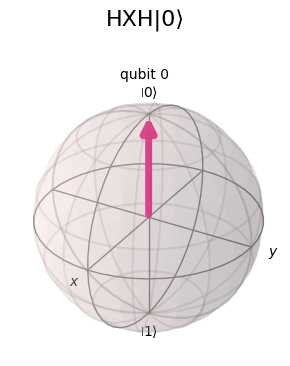

In [11]:
# Visualizamos estados en la esfera de Bloch
from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(state0, title='HXH|0⟩', figsize=(3, 3))

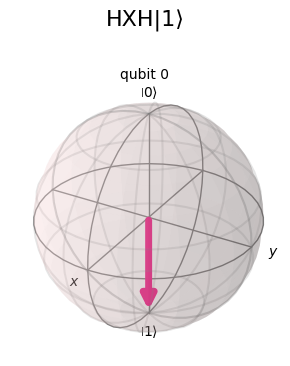

In [12]:
plot_bloch_multivector(state1, title='HXH|1⟩', figsize=(3, 3))

## 5. Conclusión

La igualdad $HXH=Z$ es una **identidad de circuitos**, útil para simplificar y optimizar circuitos cuánticos sin cambiar su efecto.

## 5. Referencias
### Referencias
1. D. McMahon. Quantum Computing Explained. IEEE Press. Wiley, 2008.
2. Thomas G. Wong. Introduction to Classical and Quantum Computing. University of Texas Rio
Grande Valley, 2021.
